# Methodology & Diagnostics

Our previous models averageed EEG accross 2-3 subjects per meme, before feeding it to the model. This projects expands to a **per subject** samples to preserve individual neural signal.

This notebooks establishes three things before any model is being test and built:

1. Who are the subjects? How many, how unevenly represented, and what threshold separates between "enoug data to trust" to "too small to use individually".
2. The Fingerprinting risk. How much does EEG alone reveal subject identity, if a model can tell who os being recorded just from the EEG features, any channel gate model risks encoding identity instead of cognition itself.
3. Distribution per subject and sexism label. If certain subject saw more sexist content, subject identity and label leak into each other. This could be another risk.

## Metrics and Labels 
- Labels: Hard labels (Majority vote). For direct comparability with our own prior results and other models.
- Metrics: Macro F1 as primary, AUC as secondary.

## Analyses on this notebook
- The fingerprinting risk
- Label/Subject Distribution
- The Split Functions: Leave-Meme-Out and Leave-Subject-Out.

In [1]:
#Libraries
import os
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix
from scipy.stats import chi2_contingency


#Format plots
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

#SEED 
RANDOM_STATE = 42

os.chdir("C:/Users/diego/Desktop/multimodal-eeg-spatial-gates")

In [2]:
#Paths
REPO_ROOT = "C:/Users/diego/Desktop/multimodal-eeg-spatial-gates"
DATA_PATH = Path(REPO_ROOT) / "data" / "processed" / "train_base.parquet"
OUT_DIR = Path(REPO_ROOT) / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
#Read data
df = pd.read_parquet(DATA_PATH)
BANDS = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
EEG_COLS = [f"EXG_Channel_{ch}_{band}_power" for ch in range(16) for band in BANDS]
print(f"Shape: {df.shape}")
df.head(3)

Shape: (8090, 104)


,meme_id,subject_id,lang,text,image_file,split,n_eeg_subjects,EXG_Channel_0_Delta_power,EXG_Channel_0_Theta_power,EXG_Channel_0_Alpha_power,...,cat_hard_stereotyping_dominance,cat_hard_objectification,cat_hard_sexual_violence,cat_hard_misogyny_nsv,cat_soft_ideological_inequality,cat_soft_stereotyping_dominance,cat_soft_objectification,cat_soft_sexual_violence,cat_soft_misogyny_nsv,categories_valid
0,110887,ES1,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,2,-0.5379,-0.6630,-0.6211,...,0,1,0,1,0.166667,0.166667,0.666667,0.000000,0.500000,True
1,110887,ES3,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,2,-0.3520,-0.3575,-0.0700,...,0,1,0,1,0.166667,0.166667,0.666667,0.000000,0.500000,True
2,110466,ES1,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,2,0.4666,0.0987,0.7818,...,1,0,1,0,0.166667,0.500000,0.166667,0.333333,0.166667,True


## A very short EDA

In [4]:
print(f"Total rows (meme per subject): {len(df):,}")
print(f"Unique memes: {df['meme_id'].nunique():,}")
print(f"Unique subjects: {df['subject_id'].nunique()}")
print(f"Languages: {df['lang'].value_counts().to_dict()}")
print(f"Overall % sexist (hard): {df['sexist_hard'].mean():.3f}")

subj_per_meme = df.groupby("meme_id")["subject_id"].count()
print(f"\nEEG subjects per meme: \n{subj_per_meme.value_counts().sort_index()}")

Total rows (meme per subject): 8,090
Unique memes: 3,984
Unique subjects: 12
Languages: {'en': 4059, 'es': 4031}
Overall % sexist (hard): 0.658

EEG subjects per meme: 
subject_id
2    3862
3     122
Name: count, dtype: int64


## Our subject distribution

In our dataset we have 12 unique subjects but with very uneven coverage. Some of them saw more than 1,000 memes, others less than 100.

We define "well-representd" as $\geq$ 500 memes. This is enough for a stable per-subject estimations and analyses. Below that, the fold would be fominated by sampling noise for another individual that significant signal.

Therefore, marginal subjects stay in **training only** for the rest of the project. They can contribute, but they never get evaluated individually.

In [5]:
#Our threshold for well-represented subjects
SUBJECT_THRESHOLD = 500

subj_counts = df["subject_id"].value_counts()
well_represented = subj_counts[subj_counts >= SUBJECT_THRESHOLD].index.tolist()
marginal = subj_counts[subj_counts <  SUBJECT_THRESHOLD].index.tolist()

summary = pd.DataFrame({
    "subject_id": subj_counts.index,
    "n_memes": subj_counts.values,
    "pct_total": (subj_counts.values / len(df) * 100).round(2),
    "lang": [df.loc[df["subject_id"] == s, "lang"].iloc[0] for s in subj_counts.index],
    "role":["well_represented" if s in well_represented else "marginal" for s in subj_counts.index]})

print(f"Well-represented (n={len(well_represented)}): {well_represented}")
print(f"Marginal (n={len(marginal)}): {marginal}\n")
summary

Well-represented (n=8): ['ES1', 'EN6', 'EN1', 'EN5', 'ES5', 'ES3', 'EN3', 'ES4']
Marginal (n=4): ['ES2', 'EN7', 'ES8', 'EN2']



,subject_id,n_memes,pct_total,lang,role
0,ES1,1075,13.29,es,well_represented
1,EN6,1052,13.00,en,well_represented
2,EN1,1031,12.74,en,well_represented
3,EN5,1027,12.69,en,well_represented
4,ES5,1025,12.67,es,well_represented
5,ES3,1015,12.55,es,well_represented
6,EN3,826,10.21,en,well_represented
7,ES4,820,10.14,es,well_represented
8,ES2,87,1.08,es,marginal
9,EN7,67,0.83,en,marginal


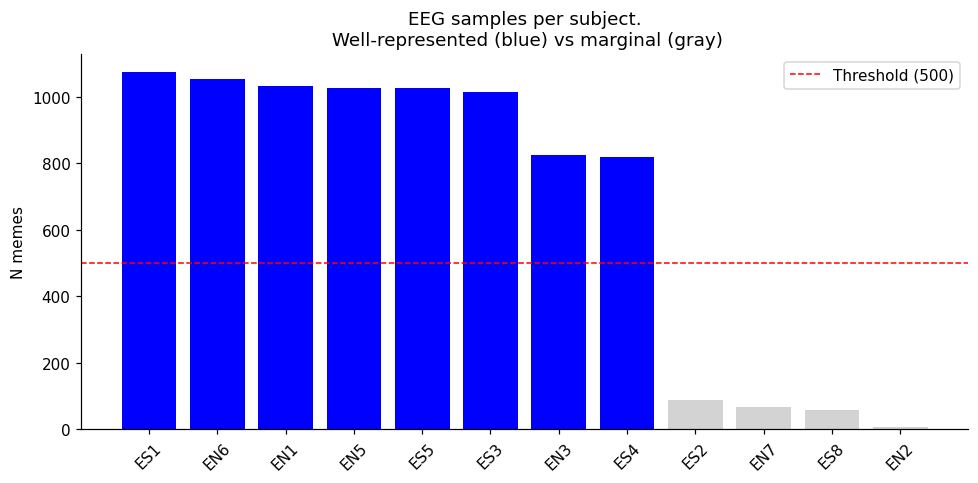

In [6]:
#EEG samples per subject (Well-represented vs marginal)
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["blue" if r == "well_represented" else "lightgray" for r in summary["role"]]
ax.bar(summary["subject_id"], summary["n_memes"], color=colors)
ax.axhline(SUBJECT_THRESHOLD, color="Red", linestyle="--", linewidth=1, label=f"Threshold ({SUBJECT_THRESHOLD})")
ax.set_ylabel("N memes")
ax.set_title("EEG samples per subject.\n Well-represented (blue) vs marginal (gray)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Validation Approach

Since we are dealing meme per subject we propose 2 complementary cross-validation schemes, that will help us to answer two different questions:


| | **Leave-Meme-Out** (primary) | **Leave-Subject-Out** (ablation) |
|---|---|---|
| Question | Does the model understand *meme content*? | Does the model generalize to a *new individual's* EEG? |
| Approachj | A meme that is never seen in both train/val | A whole subject that is never seen in both train/val |
| Folds | 5 (stratified by sexist_hard, grouped by meme_id) | 8 (one per well-represented subject) |
| Used for | Performance metrics (Macro F1, AUC) | Diagnostic. Quantifies reliance on subject identity |

The gap between the two is an interesting finding because if Leave-Meme-Out F1 > Leave-Subject-Out F1, the model leans on neural identity more than on meme content. Thats why we are running a fingerprinting diagnostic below.

In [9]:
#We initialize the splitters so we can test them and see how many memes and subjects are in each fold.

def leave_meme_out_splits(dframe, label_col="sexist_hard", group_col="meme_id",
                          n_folds=5, seed=RANDOM_STATE):
    """
    This is our primary CV. 
    Groups by meme_id so the same meme never appeears in the train and val dataset. 
    Stratifies by labl_col so class balance is preserved per fold.
    Subjects may repeat across train/val (with different memes).
    """

    sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    X_dummy = np.zeros(len(dframe))
    groups  = dframe[group_col].to_numpy()
    labels  = dframe[label_col].to_numpy()
    for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_dummy, labels, groups=groups)):
        yield fold, train_idx, val_idx


def leave_subject_out_splits(dframe, eligible_subjects, subject_col="subject_id"):
    """
    This is our ablation CV. 
    Each fold excludes ONE eligible subject entirely from train and evaluates only on that subject's memes. 
    Marginal subjects they stay in train every fold.
"""
    idx_array = np.arange(len(dframe))
    subj_arr  = dframe[subject_col].to_numpy()
    for held_out in eligible_subjects:
        val_idx   = idx_array[subj_arr == held_out]
        train_idx = idx_array[subj_arr != held_out]
        yield held_out, train_idx, val_idx

In [10]:
print("Leave-Meme-Out (5 folds): ")
for fold, tr_idx, val_idx in leave_meme_out_splits(df):
    overlap = set(df.iloc[tr_idx]["meme_id"]) & set(df.iloc[val_idx]["meme_id"])
    val_rate = df.iloc[val_idx]["sexist_hard"].mean()
    print(f"Fold {fold}: train={len(tr_idx):>5}  val={len(val_idx):>5}  "
          f"meme_overlap={len(overlap)}  val_sexist_rate={val_rate:.3f}")

print("\nLeave-Subject-Out (well-represented only): ")
for held_out, tr_idx, val_idx in leave_subject_out_splits(df, well_represented):
    subj_leak = set(df.iloc[tr_idx]["subject_id"]) & {held_out}
    print(f"Held out {held_out}: train={len(tr_idx):>5}  val={len(val_idx):>5}  "
          f"subject_leak={len(subj_leak)}")

Leave-Meme-Out (5 folds): 
Fold 0: train= 6479  val= 1611  meme_overlap=0  val_sexist_rate=0.662
Fold 1: train= 6476  val= 1614  meme_overlap=0  val_sexist_rate=0.652
Fold 2: train= 6467  val= 1623  meme_overlap=0  val_sexist_rate=0.681
Fold 3: train= 6470  val= 1620  meme_overlap=0  val_sexist_rate=0.656
Fold 4: train= 6468  val= 1622  meme_overlap=0  val_sexist_rate=0.638

Leave-Subject-Out (well-represented only): 
Held out ES1: train= 7015  val= 1075  subject_leak=0
Held out EN6: train= 7038  val= 1052  subject_leak=0
Held out EN1: train= 7059  val= 1031  subject_leak=0
Held out EN5: train= 7063  val= 1027  subject_leak=0
Held out ES5: train= 7065  val= 1025  subject_leak=0
Held out ES3: train= 7075  val= 1015  subject_leak=0
Held out EN3: train= 7264  val=  826  subject_leak=0
Held out ES4: train= 7270  val=  820  subject_leak=0


---
## Fingerprinting risk

The idea behind is that from the EEG Band Power Features alones (80), with no meme, no text, no image, can we tell which person this is?

If the answer is "easy" classfid, every interpretability model could be encoding "Who is wearing the cap" instead of "What cognitive process the meme triggered". EEG "brainprint" biometrics is common phenomenon in BCI research, inidividuals neural signatures are strong.

We test a the simplest classifier (multinomial LR). If the simplest model identifies subjects well, a more powerfull model certainly can too.

In [11]:
# We train a multinomial Logistic Regression on raw EEG features to predict subject_id. 
# This is a "fingerprinting" diagnostic to see if the EEG features are unique enough to identify subjects. 
# We report balanced accuracy, macro F1, per-class F1, and the majority-class / chance baselines for comparison.

def fingerprint_diagnostic(dframe, subject_subset=None, test_size=0.2, seed=RANDOM_STATE):

    data = dframe if subject_subset is None else dframe[dframe["subject_id"].isin(subject_subset)]

    X = data[EEG_COLS].to_numpy(dtype=np.float64)
    y = data["subject_id"].to_numpy()


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=seed)

    scaler = StandardScaler()
    X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    #Metrics
    bal_acc  = balanced_accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    classes      = sorted(np.unique(y))
    per_class_f1 = f1_score(y_test, y_pred, average=None, labels=classes, zero_division=0)

    majority_class   = Counter(y_train).most_common(1)[0][0]
    baseline_bal_acc = balanced_accuracy_score(y_test, [majority_class] * len(y_test))
    chance_bal_acc   = 1 / len(classes)

    return {
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "baseline_balanced_accuracy": baseline_bal_acc,
        "chance_balanced_accuracy": chance_bal_acc,
        "per_class_f1": dict(zip(classes, per_class_f1)),
        "y_test": y_test, "y_pred": y_pred, "classes": classes}

In [13]:
result_all = fingerprint_diagnostic(df)
print("Fingerprinting - all 12 subjects\n")
print(f"Balanced accuracy: {result_all['balanced_accuracy']:.3f}")
print(f"Macro F1: {result_all['macro_f1']:.3f}")
print(f"Majority-class baseline: {result_all['baseline_balanced_accuracy']:.3f}")
print(f"Chance level (1/12): {result_all['chance_balanced_accuracy']:.3f}")
print("\nPer-subject identifiability (F1, sorted):")
for s, f1 in sorted(result_all["per_class_f1"].items(), key=lambda x: -x[1]):
    print(f"{s}: {f1:.3f}")

Fingerprinting - all 12 subjects

Balanced accuracy: 0.847
Macro F1: 0.808
Majority-class baseline: 0.083
Chance level (1/12): 0.083

Per-subject identifiability (F1, sorted):
ES5: 0.983
EN3: 0.976
EN6: 0.960
EN5: 0.949
ES4: 0.945
ES3: 0.938
EN1: 0.933
ES1: 0.912
ES8: 0.737
EN7: 0.690
ES2: 0.510
EN2: 0.167


In [15]:
#Only well-represented subjects
result_wr = fingerprint_diagnostic(df, subject_subset=well_represented)
print("Fingerprinting — 8 well-represented subjects only")
print(f"Balanced accuracy: {result_wr['balanced_accuracy']:.3f}")
print(f"Chance level (1/8): {result_wr['chance_balanced_accuracy']:.3f}")

Fingerprinting — 8 well-represented subjects only
Balanced accuracy: 0.960
Chance level (1/8): 0.125


### Interpretation:

These results were expected. EEG biometrics, or “brainprints,” are well documented in BCI research. Even using compact band-power features, subject identity can still be recovered with high accuracy. In our dataset, a simple linear model reached 0.960 balanced accuracy, compared with a chance level of 0.125. This shows that subject identity is a strong signal in the data.

The increase from 0.847 with 12 subjects to 0.960 with 8 subjects is not by chance, the lower score with 12 subjects was affected by four poorly represented subjects, who had too few sample. Therefore, the 8-subject result gives a cleaner estimate of the identity signal in the well-represented part of the dataset.

For our main research question, this is an important warning. If our future models identifies certain channels or bands as important, they may partly reflect subject identity. A neurophysiological interpretation should rely on patterns that are consistent across subjects.

A future analysis could be compare the channels and bands used by the fingerprinting classifier with those highlighted by the spatial gates. Strong overlap would suggest that some “important” gates may be capturing subject identity information.

---

## Label-Subject distribution (Diagnostic)

What happens if certain subjects saw more sexist memes than others? If so, subject_id and hard_label could be entangled. The model could use identitiy as a shortcut to the label, not just the neuronal patterns.

We test this with a chi-square test of independece between  `subject_id` and `sexist_hard`, and report it alongside the p-value.

In [19]:
crosstab = pd.crosstab(df["subject_id"], df["sexist_hard"])
chi2, p_val, dof, expected = chi2_contingency(crosstab)

n_total  = crosstab.sum().sum()
min_dim  = min(crosstab.shape[0] - 1, crosstab.shape[1] - 1)
cramers_v = np.sqrt(chi2 / (n_total * min_dim))

print(f"Chi-square = {chi2:.2f}, dof = {dof}, p-value = {p_val:.6f}")
print(f"Cramér's V = {cramers_v:.4f}")

overall_rate = df["sexist_hard"].mean()
pct_by_subj  = df.groupby("subject_id")["sexist_hard"].mean().sort_values(ascending=False)
n_by_subj    = df["subject_id"].value_counts()

print(f"\nOverall % sexist: {overall_rate:.3f}\n")
for s, pct in pct_by_subj.items():
    role = "well_rep" if s in well_represented else "marginal"
    print(f"  {s:>4} (n={n_by_subj[s]}, {role}): {pct:.3f}  (Δ={pct - overall_rate:+.3f})")

Chi-square = 31.29, dof = 11, p-value = 0.000991
Cramér's V = 0.0622

Overall % sexist: 0.658

   EN7 (n=67, marginal): 0.716  (Δ=+0.059)
   EN2 (n=7, marginal): 0.714  (Δ=+0.057)
   ES8 (n=58, marginal): 0.707  (Δ=+0.049)
   ES5 (n=1025, well_rep): 0.697  (Δ=+0.039)
   ES3 (n=1015, well_rep): 0.689  (Δ=+0.031)
   ES1 (n=1075, well_rep): 0.681  (Δ=+0.023)
   ES2 (n=87, marginal): 0.678  (Δ=+0.020)
   ES4 (n=820, well_rep): 0.668  (Δ=+0.011)
   EN6 (n=1052, well_rep): 0.634  (Δ=-0.024)
   EN5 (n=1027, well_rep): 0.633  (Δ=-0.025)
   EN1 (n=1031, well_rep): 0.628  (Δ=-0.030)
   EN3 (n=826, well_rep): 0.619  (Δ=-0.039)


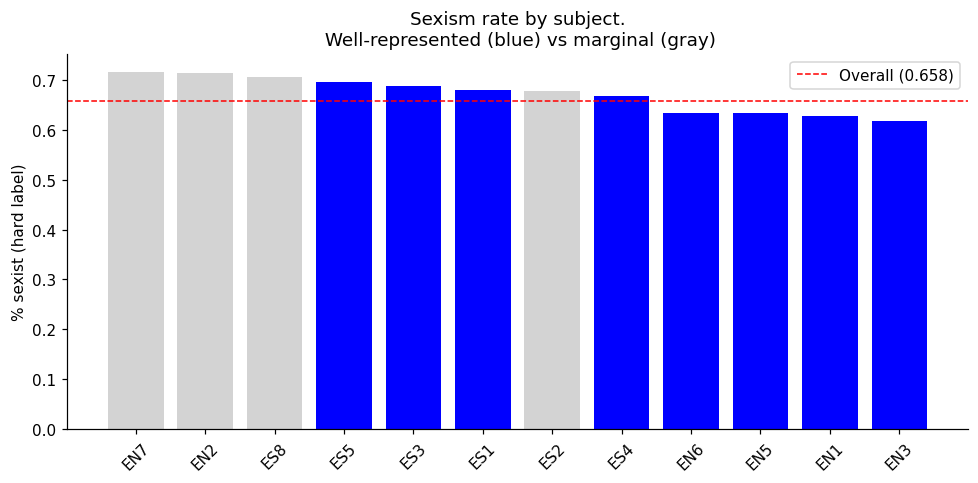

In [24]:
#Plot % sexist by subject, highlighting well-represented vs marginal subjects
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["blue" if s in well_represented else "lightgray" for s in pct_by_subj.index]
ax.bar(pct_by_subj.index, pct_by_subj.values, color=colors)
ax.axhline(overall_rate, color="red", linestyle="--", linewidth=1, label=f"Overall ({overall_rate:.3f})")
ax.set_ylabel("% sexist (hard label)")
ax.set_title("Sexism rate by subject.\n Well-represented (blue) vs marginal (gray)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation:

The confound is statistically real, with p = 0.001, but its effect size is negligible, with Cramér’s V = 0.062 very small. This means that subject_id is not introducing a hidden bias toward any specific hard label (sexism). What initially looked like an identity confound is mostly a visible property of the dataset, which any multimodal model would already handle implicitly.

---

## In conclusion, what we found: 

### Fingerprinting: real and strong

A simple Logistic Regression on EEG features alone identifies which of 12 subjects is. This is not a boerderline result, EEG carries an individual signature strong enough that a trivial model recovers identity almos perfectly.

The consequence is the channel gate maps cannot be interpreted as purely cognitive driven without a caveat. We will report gate values per subject, and then treat cross subject to measure consistency of regional patters.

### Label-Subject distribution: statistically present, practically negligible

The chi-square test is significant (p ≈ 0.001), but Cramér's V ≈ 0.06 is below the negligible threshold. No special re-weighting or other techniques is needed for the well-represented subjects.